<a href="https://colab.research.google.com/github/RIDDHI1624/Drug-Discovery/blob/main/Insulin_Receptor_Project/INSR_Curriculum_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INSR Curriculum Learning — Step 4
**Project:** Insulin Receptor (INSR) — Phase 2 De Novo Campaign

| Stage | Epochs | Batch | Active Components |
|-------|--------|-------|------------------|
| 1 — Property Opt | 1–100 | 128 | QED + ALogP + SA |
| 2 — Structure-Based | 101–300 | 64 | + Vina (parallel) |
| 3 — Selectivity | 301–500 | 64 | + Pharmacophore + Steric |

> **Run after Cells 1-7 of INSR_Scoring_Function.ipynb** — scoring functions must be in memory.

In [1]:
import subprocess, sys, importlib, numpy as np, warnings
warnings.filterwarnings('ignore')

subprocess.run(['pip','install','-q','rdkit','numpy','scipy','pandas','matplotlib'])
subprocess.run(['wget','-q','-O','sascorer.py',
    'https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py'])
subprocess.run(['wget','-q','-O','fpscores.pkl.gz',
    'https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz'])

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
from rdkit.Chem import QED as rdQED
from rdkit.Geometry import rdGeometry
import importlib.util
spec = importlib.util.spec_from_file_location('sascorer','sascorer.py')
sascorer = importlib.util.module_from_spec(spec)
spec.loader.exec_module(sascorer)

IGF1R_VAL1063_COORD = (10.026, 13.400, -1.313)
INSR_ILE1061_CB     = (7.515,  13.711,  0.839)
IGF1R_VAL1063_CB    = (7.515,  13.711,  0.839)
SELECTIVITY_RADIUS  = 3.5
INSR_EXCL_R         = 2.40
IGF1R_EXCL_R        = 2.00
VDW_RADII = {'C':1.70,'N':1.55,'O':1.52,'S':1.80,'F':1.47,'Cl':1.75,'Br':1.85,'I':1.98,'P':1.80,'H':1.20}

def get_3d_mol(smiles, n_confs=3):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    mol = Chem.AddHs(mol)
    p = AllChem.ETKDGv3(); p.randomSeed=42; p.numThreads=0
    ids = AllChem.EmbedMultipleConfs(mol, numConfs=n_confs, params=p)
    if not ids: return None
    energies = []
    for cid in ids:
        ff = AllChem.MMFFGetMoleculeForceField(mol, AllChem.MMFFGetMoleculeProperties(mol), confId=cid)
        if ff: ff.Minimize(); energies.append((ff.CalcEnergy(), cid))
    if not energies: return None
    best = min(energies)[1]
    [mol.RemoveConformer(c) for c in list(ids) if c != best]
    return Chem.RemoveHs(mol)

def score_vina(vina_score, low=-12.0, high=-6.0):
    return float(1.0/(1.0+np.exp(0.5*(vina_score-(low+high)/2))))

def score_selectivity(smiles):
    mol = get_3d_mol(smiles)
    if mol is None or mol.GetNumConformers()==0: return 0.5
    conf = mol.GetConformer()
    ref  = rdGeometry.Point3D(*IGF1R_VAL1063_COORD)
    don  = Chem.MolFromSmarts('[#7,#8;!H0]')
    idxs = set(sum(mol.GetSubstructMatches(don),()))
    n = sum(1 for i in idxs if ref.Distance(rdGeometry.Point3D(*conf.GetAtomPosition(i)))<=SELECTIVITY_RADIUS)
    return float(np.clip(1.0 - n*0.25, 0, 1))

def vdw_overlap(mol, coord, radius):
    if mol.GetNumConformers()==0: return 0.0
    conf=mol.GetConformer(); rx,ry,rz=coord; total=0.0
    for a in mol.GetAtoms():
        if a.GetAtomicNum()==1: continue
        p=conf.GetAtomPosition(a.GetIdx())
        d=np.sqrt((p.x-rx)**2+(p.y-ry)**2+(p.z-rz)**2)
        total+=max(0.0, VDW_RADII.get(a.GetSymbol(),1.70)+radius-d)
    return total

def score_steric(smiles):
    mol=get_3d_mol(smiles)
    if mol is None: return 0.5
    d=vdw_overlap(mol,IGF1R_VAL1063_CB,IGF1R_EXCL_R)-vdw_overlap(mol,INSR_ILE1061_CB,INSR_EXCL_R)
    return float(1.0/(1.0+np.exp(-d)))

def score_qed(smiles):
    mol=Chem.MolFromSmiles(smiles)
    if mol is None: return 0.0
    try: return float(rdQED.qed(mol))
    except: return 0.0

def score_alogp(smiles, low=2.0, high=4.5, k=2.0):
    mol=Chem.MolFromSmiles(smiles)
    if mol is None: return 0.0
    try: a=Descriptors.MolLogP(mol)
    except: return 0.0
    return float(np.clip((1/(1+np.exp(-k*(a-low))))*(1/(1+np.exp(-k*(high-a))))*4,0,1))

def score_sa(smiles, threshold=4.0):
    mol=Chem.MolFromSmiles(smiles)
    if mol is None: return 0.0
    try: raw=sascorer.calculateScore(mol)
    except: raw=5.0
    return float(np.clip(1.0/(1.0+np.exp(1.5*(raw-threshold))),0,1))

print(' All 6 scoring functions ready.')

 All 6 scoring functions ready.


In [4]:
import os
os.environ['OMP_NUM_THREADS'] = '4'
print(' CPU threading enabled.')

 CPU threading enabled.


In [6]:
# Cell A — Mock Generator
# Lightweight SMILES generator via random mutation.
# Replace MockGenerator with REINVENT4 agent for production.

import random
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from rdkit import Chem
from rdkit.Chem import AllChem

SEED_SMILES = [
    'C1=CC=C2C(=C1)C(=CN2)CCCCN',
    'COc1ccc2CC3N(Cc4cc5c(cc4-3)OCO5)CCc2c1OC',
    'Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1',
    'c1ccc2[nH]ccc2c1',
    'O=C(Nc1ccccc1)c1ccccc1',
    'Cc1ccc(-c2cc(C(F)(F)F)nn2-c2ccc(S(N)(=O)=O)cc2)cc1',
    'CC(C)Cc1ccc(C(C)C(=O)O)cc1',
    'c1ccc(-c2ccncc2)cc1',
    'CC1=C(C(=O)Nc2ccccc2)C(c2ccccc2)NC(=O)N1',
    'O=C(O)c1ccccc1Nc1cccc2ccccc12',
]

MUTATIONS = [
    lambda s: s.replace('CC', 'CCC', 1),
    lambda s: s.replace('N', 'NC', 1),
    lambda s: s.replace('c1ccccc1', 'c1ccncc1', 1),
    lambda s: s.replace('O', 'OC', 1),
    lambda s: s + 'C',
    lambda s: s.replace('C(=O)', 'C(=O)N', 1),
]

class MockGenerator:
    def __init__(self, seed_pool=SEED_SMILES):
        self.pool = list(seed_pool)

    def sample(self, n: int):
        candidates, attempts = [], 0
        while len(candidates) < n and attempts < n * 20:
            attempts += 1
            try:
                mutated = random.choice(MUTATIONS)(random.choice(self.pool))
                mol = Chem.MolFromSmiles(mutated)
                if mol is not None:
                    candidates.append(Chem.MolToSmiles(mol))
            except Exception:
                continue
        while len(candidates) < n:
            candidates.append(random.choice(self.pool))
        return candidates

    def update(self, smiles_list, scores):
        new_good = [s for s, sc in zip(smiles_list, scores) if sc >= 0.65]
        if new_good:
            self.pool.extend(new_good)
            if len(self.pool) > 500:
                self.pool = self.pool[-500:]

generator = MockGenerator()
print(' MockGenerator ready.')
print(f'   Seed pool: {len(generator.pool)} molecules')
print('   Replace with REINVENT4 agent for production.')

 MockGenerator ready.
   Seed pool: 10 molecules
   Replace with REINVENT4 agent for production.


In [7]:
# Cell A1 — Stage Configuration + Scoring

from concurrent.futures import ThreadPoolExecutor, as_completed
from typing import List, Dict, Tuple, Optional

STAGE_CONFIG = {
    1: {
        'name': 'Property Optimization',
        'epochs': (1, 100),
        'batch_size': 128,
        'lr': 1e-4,
        'weights': {'vina':0.00,'selectivity':0.00,'steric':0.00,'qed':0.40,'alogp':0.30,'sa':0.30},
        'docking': False,
        'selectivity': False,
    },
    2: {
        'name': 'Structure-Based Scoring',
        'epochs': (101, 300),
        'batch_size': 64,
        'lr': 1e-4,
        'weights': {'vina':0.45,'selectivity':0.00,'steric':0.00,'qed':0.25,'alogp':0.15,'sa':0.15},
        'docking': True,
        'selectivity': False,
    },
    3: {
        'name': 'Selectivity Refinement',
        'epochs': (301, 500),
        'batch_size': 32,
        'lr': 5e-5,
        'weights': {'vina':0.35,'selectivity':0.15,'steric':0.15,'qed':0.15,'alogp':0.10,'sa':0.10},
        'docking': True,
        'selectivity': True,
    },
}

def get_stage(epoch: int) -> int:
    for stage, cfg in STAGE_CONFIG.items():
        lo, hi = cfg['epochs']
        if lo <= epoch <= hi:
            return stage
    return 3

def mock_vina_score(smiles: str) -> float:
    """
    Mock Vina call. Replace with real subprocess for production:
      vina --receptor receptor.pdbqt --ligand lig.pdbqt
           --center_x 7.5 --center_y 13.7 --center_z 0.8
           --size_x 25 --size_y 25 --size_z 25
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return -5.0
    n_atoms = mol.GetNumHeavyAtoms()
    n_rings = mol.GetRingInfo().NumRings()
    score = -5.0 - (n_atoms * 0.08) - (n_rings * 0.5) + np.random.normal(0, 0.5)
    return float(np.clip(score, -14.0, -3.0))

def score_molecule_staged(args: Tuple) -> Dict:
    smiles, stage, vina_score = args
    cfg = STAGE_CONFIG[stage]
    w   = cfg['weights']
    c_qed   = score_qed(smiles)
    c_alogp = score_alogp(smiles)
    c_sa    = score_sa(smiles)
    c_vina  = score_vina(vina_score) if (cfg['docking'] and vina_score is not None) else 0.0
    c_sel   = score_selectivity(smiles) if cfg['selectivity'] else 0.0
    c_ster  = score_steric(smiles)      if cfg['selectivity'] else 0.0
    components = {'vina':c_vina,'selectivity':c_sel,'steric':c_ster,
                  'qed':c_qed,'alogp':c_alogp,'sa':c_sa}
    total = float(np.clip(sum(w[k]*v for k,v in components.items()), 0.0, 1.0))
    return {'smiles': smiles, 'total': total, **components}

def dock_batch_parallel(smiles_list: List[str], n_workers: int = 4) -> Dict[str, float]:
    results = {}
    with ThreadPoolExecutor(max_workers=n_workers) as ex:
        futures = {ex.submit(mock_vina_score, smi): smi for smi in smiles_list}
        for fut in as_completed(futures):
            results[futures[fut]] = fut.result()
    return results

print(' Stage config + scoring functions ready.')
for s, cfg in STAGE_CONFIG.items():
    print(f'   Stage {s}: {cfg["name"]} | Epochs {cfg["epochs"]} | Batch {cfg["batch_size"]}')

 Stage config + scoring functions ready.
   Stage 1: Property Optimization | Epochs (1, 100) | Batch 128
   Stage 2: Structure-Based Scoring | Epochs (101, 300) | Batch 64
   Stage 3: Selectivity Refinement | Epochs (301, 500) | Batch 32


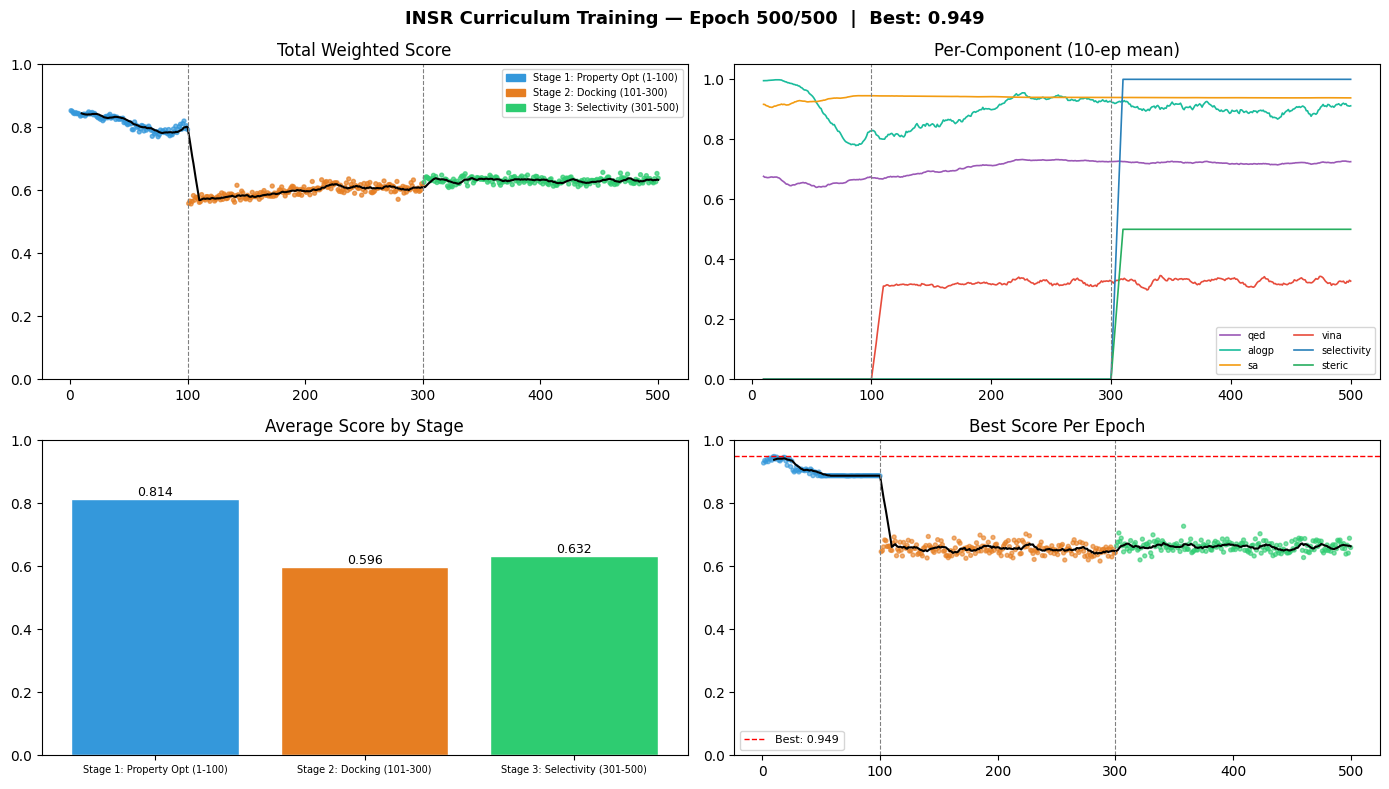

  Best ever: 0.9488 | Cc1ccccc1CCNC(=O)c1ccccc1C
  Elapsed  : 2036s


  Training complete — 500 epochs
  Best score : 0.9488
  Best SMILES: Cc1ccccc1CCNC(=O)c1ccccc1C


In [8]:
# Cell A2 — Main Curriculum Training Loop (500 Epochs)

import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import clear_output

history = {
    'epoch':[],'stage':[],'batch_size':[],'total':[],
    'vina':[],'selectivity':[],'steric':[],'qed':[],'alogp':[],'sa':[],
    'best_smiles':[],'best_score':[],
}

TOTAL_EPOCHS = 500
LOG_EVERY    = 10
PLOT_EVERY   = 50
N_WORKERS    = 4

best_ever_score  = 0.0
best_ever_smiles = ''

stage_colors = {1:'#3498db', 2:'#e67e22', 3:'#2ecc71'}
stage_labels = {
    1:'Stage 1: Property Opt (1-100)',
    2:'Stage 2: Docking (101-300)',
    3:'Stage 3: Selectivity (301-500)',
}

print('Starting Curriculum Training Loop')
print(f'Total epochs: {TOTAL_EPOCHS} | Log every: {LOG_EVERY} | Plot every: {PLOT_EVERY}')
print('-' * 60)
t_start = time.time()

for epoch in range(1, TOTAL_EPOCHS + 1):

    stage      = get_stage(epoch)
    cfg        = STAGE_CONFIG[stage]
    batch_size = cfg['batch_size']

    smiles_batch = generator.sample(batch_size)

    vina_scores = {}
    if cfg['docking']:
        vina_scores = dock_batch_parallel(smiles_batch, n_workers=N_WORKERS)

    scored = []
    for smi in smiles_batch:
        try:
            scored.append(score_molecule_staged((smi, stage, vina_scores.get(smi, None))))
        except Exception:
            continue
    if not scored:
        continue

    totals    = [r['total'] for r in scored]
    avg_total = float(np.mean(totals))
    avg_comp  = {k: float(np.mean([r[k] for r in scored]))
                 for k in ['vina','selectivity','steric','qed','alogp','sa']}
    best_idx  = int(np.argmax(totals))
    best_score = totals[best_idx]
    best_smi   = scored[best_idx]['smiles']

    if best_score > best_ever_score:
        best_ever_score  = best_score
        best_ever_smiles = best_smi

    generator.update(smiles_batch, totals)

    history['epoch'].append(epoch)
    history['stage'].append(stage)
    history['batch_size'].append(batch_size)
    history['total'].append(avg_total)
    history['best_smiles'].append(best_smi)
    history['best_score'].append(best_score)
    for k in ['vina','selectivity','steric','qed','alogp','sa']:
        history[k].append(avg_comp[k])

    if epoch % LOG_EVERY == 0 or epoch == 1:
        print(f'  Epoch {epoch:>3d}/500 | Stage {stage} | '
              f'Avg={avg_total:.3f} | Best={best_score:.3f} | '
              f'QED={avg_comp["qed"]:.3f} | Vina={avg_comp["vina"]:.3f} | '
              f't={time.time()-t_start:.0f}s')

    if epoch % PLOT_EVERY == 0:
        clear_output(wait=True)
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
        fig.suptitle(f'INSR Curriculum Training — Epoch {epoch}/500  |  Best: {best_ever_score:.3f}',
                     fontsize=13, fontweight='bold')
        ep = history['epoch']
        colors = [stage_colors[s] for s in history['stage']]

        ax = axes[0,0]
        ax.scatter(ep, history['total'], c=colors, s=8, alpha=0.7)
        if len(ep)>=10: ax.plot(ep, pd.Series(history['total']).rolling(10).mean(), 'k-', lw=1.5)
        ax.axvline(100,color='gray',linestyle='--',lw=0.8); ax.axvline(300,color='gray',linestyle='--',lw=0.8)
        ax.set_title('Total Weighted Score'); ax.set_ylim(0,1)
        ax.legend(handles=[mpatches.Patch(color=c,label=stage_labels[s]) for s,c in stage_colors.items()],fontsize=7)

        ax = axes[0,1]
        for comp,col in [('qed','#9b59b6'),('alogp','#1abc9c'),('sa','#f39c12'),
                          ('vina','#e74c3c'),('selectivity','#2980b9'),('steric','#27ae60')]:
            if len(ep)>=10: ax.plot(ep, pd.Series(history[comp]).rolling(10).mean(), color=col, lw=1.2, label=comp)
        ax.axvline(100,color='gray',linestyle='--',lw=0.8); ax.axvline(300,color='gray',linestyle='--',lw=0.8)
        ax.set_title('Per-Component (10-ep mean)'); ax.set_ylim(0,1.05); ax.legend(fontsize=7,ncol=2)

        ax = axes[1,0]
        st_list = history['stage']
        avgs = {s: np.mean([history['total'][i] for i,x in enumerate(st_list) if x==s])
                for s in [1,2,3] if s in st_list}
        if avgs:
            bars = ax.bar([stage_labels[s] for s in avgs], list(avgs.values()),
                          color=[stage_colors[s] for s in avgs], edgecolor='white')
            for bar,val in zip(bars,avgs.values()):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val:.3f}', ha='center',fontsize=9)
        ax.set_title('Average Score by Stage'); ax.set_ylim(0,1); ax.tick_params(axis='x',labelsize=7)

        ax = axes[1,1]
        ax.scatter(ep, history['best_score'], c=colors, s=8, alpha=0.6)
        if len(ep)>=10: ax.plot(ep, pd.Series(history['best_score']).rolling(10).mean(),'k-',lw=1.5)
        ax.axhline(best_ever_score,color='red',linestyle='--',lw=1,label=f'Best: {best_ever_score:.3f}')
        ax.axvline(100,color='gray',linestyle='--',lw=0.8); ax.axvline(300,color='gray',linestyle='--',lw=0.8)
        ax.set_title('Best Score Per Epoch'); ax.set_ylim(0,1); ax.legend(fontsize=8)

        plt.tight_layout()
        plt.savefig(f'training_epoch_{epoch}.png', dpi=100, bbox_inches='tight')
        plt.show()
        print(f'  Best ever: {best_ever_score:.4f} | {best_ever_smiles[:60]}')
        print(f'  Elapsed  : {time.time()-t_start:.0f}s\n')

print('\n' + '='*60)
print(f'  Training complete — {TOTAL_EPOCHS} epochs')
print(f'  Best score : {best_ever_score:.4f}')
print(f'  Best SMILES: {best_ever_smiles}')
print('='*60)

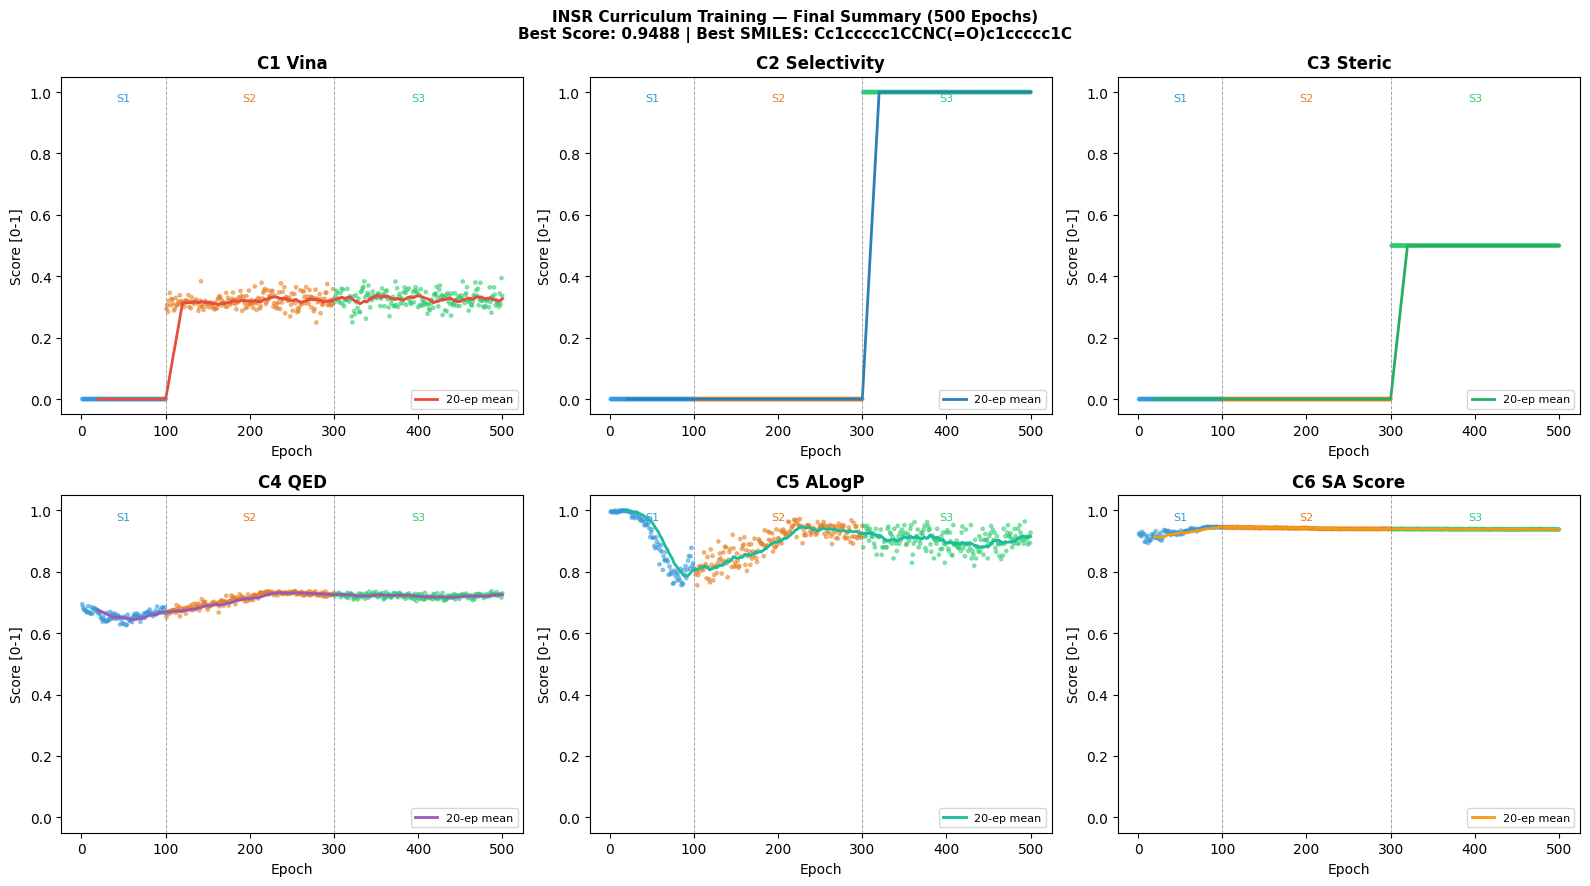

 Results saved.
Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# Cell A3 — Final Summary Plot + Save Results

from google.colab import files

df_history = pd.DataFrame(history)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(
    f'INSR Curriculum Training — Final Summary (500 Epochs)\n'
    f'Best Score: {best_ever_score:.4f} | Best SMILES: {best_ever_smiles[:50]}',
    fontsize=11, fontweight='bold'
)

components    = ['vina','selectivity','steric','qed','alogp','sa']
comp_names    = ['C1 Vina','C2 Selectivity','C3 Steric','C4 QED','C5 ALogP','C6 SA Score']
comp_cols     = ['#e74c3c','#2980b9','#27ae60','#9b59b6','#1abc9c','#f39c12']
ep = df_history['epoch'].tolist()

for i, (comp, name, col) in enumerate(zip(components, comp_names, comp_cols)):
    ax   = axes[i//3][i%3]
    vals = df_history[comp].tolist()
    st   = df_history['stage'].tolist()
    ax.scatter(ep, vals, c=[stage_colors[s] for s in st], s=6, alpha=0.5)
    ax.plot(ep, pd.Series(vals).rolling(20).mean(), color=col, lw=2, label='20-ep mean')
    ax.axvline(100,color='gray',linestyle='--',lw=0.7,alpha=0.7)
    ax.axvline(300,color='gray',linestyle='--',lw=0.7,alpha=0.7)
    ax.text(50, 0.97,'S1',ha='center',fontsize=8,color=stage_colors[1])
    ax.text(200,0.97,'S2',ha='center',fontsize=8,color=stage_colors[2])
    ax.text(400,0.97,'S3',ha='center',fontsize=8,color=stage_colors[3])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Score [0-1]')
    ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('INSR_Training_Final_Summary.png', dpi=150, bbox_inches='tight')
plt.show()

df_history.to_csv('INSR_Training_History.csv', index=False, float_format='%.4f')

with pd.ExcelWriter('INSR_Training_Report.xlsx', engine='openpyxl') as writer:
    df_history.to_excel(writer, sheet_name='History', index=False)
    summary = []
    for s in [1, 2, 3]:
        sub = df_history[df_history['stage'] == s]
        if not sub.empty:
            summary.append({
                'Stage': s,
                'Name':      STAGE_CONFIG[s]['name'],
                'Epochs':    f"{STAGE_CONFIG[s]['epochs'][0]}-{STAGE_CONFIG[s]['epochs'][1]}",
                'Avg Total': round(sub['total'].mean(), 4),
                'Max Total': round(sub['total'].max(),  4),
                'Avg QED':   round(sub['qed'].mean(),   4),
                'Avg ALogP': round(sub['alogp'].mean(), 4),
                'Avg SA':    round(sub['sa'].mean(),    4),
                'Avg Vina':  round(sub['vina'].mean(),  4),
            })
    pd.DataFrame(summary).to_excel(writer, sheet_name='Stage Summary', index=False)

print(' Results saved.')
print('Downloading...')
files.download('INSR_Training_Final_Summary.png')
files.download('INSR_Training_History.csv')
files.download('INSR_Training_Report.xlsx')